Вариант на три  
Датасет с видами транспорта https://www.kaggle.com/datasets/nadinpethiyagoda/vehicle-dataset-for-yolo  

Для оценки качества используются:  
Precision - показывает, насколько часто найденные объекты определены правильно  
Recall- показывает, какая доля реальных объектов была обнаружена  
mAP@0.5 - базовая метрика качества детекции  
mAP@0.5:0.95- более строгая метрика


In [1]:

!pip install -q ultralytics pandas matplotlib pyyaml scikit-learn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 26.2 MB/s eta 0:00:00


In [2]:

from pathlib import Path
from collections import Counter
import random
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.metrics import precision_score, recall_score, f1_score
from ultralytics import YOLO

try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    print('Ноутбук незапущен.')

DATASET_ROOT = Path('/content/drive/MyDrive/vehicle dataset')
RUNS_DIR = Path('/content/runs_lab1')
REPORTS_DIR = Path('/content/reports_lab1')
RUNS_DIR.mkdir(parents=True, exist_ok=True)

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

assert DATASET_ROOT.exists(), f'Датасета нену: {DATASET_ROOT}'
print('Dataset root:', DATASET_ROOT)
print('Device:', DEVICE)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Mounted at /content/drive
Dataset root: /content/drive/MyDrive/vehicle dataset
Device: cuda


In [3]:

classes = [line.strip() for line in (DATASET_ROOT / 'classes.txt').read_text(encoding='utf-8').splitlines() if line.strip()]

data_yaml = textwrap.dedent(f'''
path: {DATASET_ROOT}
train: train/images
val: valid/images

names:
{chr(10).join(f'  {idx}: {name}' for idx, name in enumerate(classes))}
''').strip()

DATA_YAML_PATH = Path('/content/data.yaml')
DATA_YAML_PATH.write_text(data_yaml, encoding='utf-8')
print(DATA_YAML_PATH.read_text(encoding='utf-8'))


path: /content/drive/MyDrive/vehicle dataset
train: train/images
val: valid/images

names:
  0: car
  1: threewheel
  2: bus
  3: truck
  4: motorbike
  5: van


In [5]:

def count_files(folder: Path) -> int:
    return sum(1 for item in folder.iterdir() if item.is_file())

def count_labels(label_dir: Path) -> Counter:
    counter = Counter()
    for label_path in sorted(label_dir.glob('*.txt')):
        for line in label_path.read_text(encoding='utf-8').splitlines():
            if line.strip():
                counter[int(line.split()[0])] += 1
    return counter

print('1 выбор начальных условий')
print('Классы:', ', '.join(classes))
print()

rows = []
for split in ('train', 'valid'):
    image_dir = DATASET_ROOT / split / 'images'
    label_dir = DATASET_ROOT / split / 'labels'
    label_counts = count_labels(label_dir)
    rows.append({
        'split': split,
        'images': count_files(image_dir),
        'labels': count_files(label_dir),
    })

    print(f'[{split}]')
    print('images:', count_files(image_dir))
    print('labels:', count_files(label_dir))
    print('objects per class:')
    for class_id, class_name in enumerate(classes):
        print(f'  - {class_name}: {label_counts[class_id]}')
    print()

analysis_df = pd.DataFrame(rows)
analysis_df


1 выбор начальных условий
Классы: car, threewheel, bus, truck, motorbike, van

[train]
images: 2100
labels: 2100
objects per class:
  - car: 461
  - threewheel: 482
  - bus: 403
  - truck: 478
  - motorbike: 483
  - van: 378

[valid]
images: 900
labels: 900
objects per class:
  - car: 201
  - threewheel: 227
  - bus: 185
  - truck: 151
  - motorbike: 216
  - van: 170



,split,images,labels
0,train,2100,2100
1,valid,900,900


функции для несамосточтельной и самостоятельной реализации


In [17]:

def run_experiment(model_name: str, epochs: int, imgsz: int, batch: int, run_name: str) -> tuple[dict, Path]:
    model = YOLO(model_name)
    model.train(
        data=str(DATA_YAML_PATH),
        epochs=epochs,
        imgsz=imgsz,
        batch=batch,
        project=str(RUNS_DIR),
        name=run_name,
        device=DEVICE,
        pretrained=True,
        plots=True,
        verbose=True,
    )

    best_weights = RUNS_DIR / run_name / 'weights' / 'best.pt'
    trained_model = YOLO(str(best_weights))
    metrics = trained_model.val(
        data=str(DATA_YAML_PATH),
        imgsz=imgsz,
        split='val',
        device=DEVICE,
        plots=True,
        verbose=True,
    )

    summary = {
        'run_name': run_name,
        'model': model_name,
        'epochs': epochs,
        'imgsz': imgsz,
        'batch': batch,
        'precision': float(metrics.box.mp),
        'recall': float(metrics.box.mr),
        'map50': float(metrics.box.map50),
        'map50_95': float(metrics.box.map),
        'weights_path': str(best_weights),
    }
    return summary, best_weights

class DetectionClassificationDataset(Dataset):
    def __init__(self, image_dir: Path, label_dir: Path, image_size: int = 128, augment: bool = False):
        self.image_paths = sorted([p for p in image_dir.glob('*') if p.suffix.lower() in {'.jpg', '.jpeg', '.png'}])
        self.label_dir = label_dir
        self.image_size = image_size
        self.augment = augment
        self.num_classes = len(classes)

        transform_list = [transforms.Resize((image_size, image_size))]
        if augment:
            transform_list.extend([
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            ])
        transform_list.extend([
            transforms.ToTensor(),
        ])
        self.transform = transforms.Compose(transform_list)
        self.class_counts = self._compute_class_counts()

    def _read_labels(self, image_path: Path) -> np.ndarray:
        label_path = self.label_dir / f'{image_path.stem}.txt'
        labels = np.zeros(self.num_classes, dtype=np.float32)
        if label_path.exists():
            for line in label_path.read_text(encoding='utf-8').splitlines():
                if line.strip():
                    class_id = int(line.split()[0])
                    labels[class_id] = 1.0
        return labels

    def _compute_class_counts(self) -> np.ndarray:
        counts = np.zeros(self.num_classes, dtype=np.float32)
        for image_path in self.image_paths:
            counts += self._read_labels(image_path)
        return counts

    def __len__(self) -> int:
        return len(self.image_paths)

    def __getitem__(self, idx: int):
        image_path = self.image_paths[idx]
        image = Image.open(image_path)
        if image.mode in ('P', 'LA') or (image.mode == 'RGBA'):
            image = image.convert('RGBA').convert('RGB')
        else:
            image = image.convert('RGB')
        image_tensor = self.transform(image)

        labels = self._read_labels(image_path)
        return image_tensor, torch.tensor(labels, dtype=torch.float32)

class SimpleVehicleDetector(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

def evaluate_custom_model(model: nn.Module, dataloader: DataLoader, criterion: nn.Module, threshold: float = 0.3) -> dict:
    model.eval()
    all_targets = []
    all_preds = []
    losses = []

    with torch.no_grad():
        for images, targets in dataloader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)
            logits = model(images)
            loss = criterion(logits, targets)
            probs = torch.sigmoid(logits)
            preds = (probs > threshold).float()

            losses.append(loss.item())
            all_targets.append(targets.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    y_true = np.vstack(all_targets)
    y_pred = np.vstack(all_preds)

    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)

    return {
        'precision': float(precision),
        'recall': float(recall),
        'f1_score': float(f1),
        'loss': float(np.mean(losses)),
    }

def train_custom_detector(run_name: str, image_size: int = 128, epochs: int = 5, batch_size: int = 32, learning_rate: float = 1e-3, augment: bool = False) -> tuple[dict, Path]:
    train_dataset = DetectionClassificationDataset(
        DATASET_ROOT / 'train' / 'images',
        DATASET_ROOT / 'train' / 'labels',
        image_size=image_size,
        augment=augment,
    )
    valid_dataset = DetectionClassificationDataset(
        DATASET_ROOT / 'valid' / 'images',
        DATASET_ROOT / 'valid' / 'labels',
        image_size=image_size,
        augment=False,
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    negatives = len(train_dataset) - train_dataset.class_counts
    pos_weight = torch.tensor(
        np.clip(negatives / np.maximum(train_dataset.class_counts, 1.0), 1.0, 10.0),
        dtype=torch.float32,
        device=DEVICE,
    )

    model = SimpleVehicleDetector(num_classes=len(classes)).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_f1 = -1.0
    best_weights_path = RUNS_DIR / f'{run_name}_custom_best.pt'

    for epoch in range(epochs):
        model.train()
        epoch_losses = []
        for images, targets in train_loader:
            images = images.to(DEVICE)
            targets = targets.to(DEVICE)

            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            epoch_losses.append(loss.item())

        val_metrics = evaluate_custom_model(model, valid_loader, criterion=criterion, threshold=0.3)
        print(f'Epoch {epoch + 1}/{epochs} - train_loss={np.mean(epoch_losses):.4f} - val_loss={val_metrics["loss"]:.4f} - val_f1={val_metrics["f1_score"]:.4f}')

        if val_metrics['f1_score'] > best_f1:
            best_f1 = val_metrics['f1_score']
            torch.save(model.state_dict(), best_weights_path)

    best_model = SimpleVehicleDetector(num_classes=len(classes)).to(DEVICE)
    best_model.load_state_dict(torch.load(best_weights_path, map_location=DEVICE))
    metrics = evaluate_custom_model(best_model, valid_loader, criterion=criterion, threshold=0.3)

    summary = {
        'run_name': run_name,
        'model': 'SimpleVehicleDetector',
        'epochs': epochs,
        'imgsz': image_size,
        'batch': batch_size,
        'precision': metrics['precision'],
        'recall': metrics['recall'],
        'map50': metrics['f1_score'],
        'map50_95': metrics['f1_score'],
        'weights_path': str(best_weights_path),
        'loss': metrics['loss'],
        'augment': augment,
        'learning_rate': learning_rate,
    }
    return summary, best_weights_path


In [7]:

baseline_config = {
    'model_name': 'yolo11n.pt',
    'epochs': 20,
    'imgsz': 640,
    'batch': 16,
    'run_name': 'baseline_colab',
}

baseline_metrics, baseline_weights = run_experiment(**baseline_config)
baseline_df = pd.DataFrame([baseline_metrics])
baseline_df


Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_colab, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

,run_name,model,epochs,imgsz,batch,precision,recall,map50,map50_95,weights_path
0,baseline_colab,yolo11n.pt,20,640,16,0.965879,0.937426,0.977327,0.902227,/content/runs_lab1/baseline_colab/weights/best.pt


Попробунм улучшить, предположим что увелечение кол-ва эпох и размера поднимут качество


In [8]:
improved_config = {
    'model_name': 'yolo11s.pt',
    'epochs': 30,
    'imgsz': 640,
    'batch': 16,
    'run_name': 'improved_colab',
}

improved_metrics, improved_weights = run_experiment(**improved_config)

improved_df = pd.DataFrame([improved_metrics])
improved_df


Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=improved_colab, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, pers

,run_name,model,epochs,imgsz,batch,precision,recall,map50,map50_95,weights_path
0,improved_colab,yolo11s.pt,30,640,16,0.964509,0.929293,0.97629,0.905187,/content/runs_lab1/improved_colab/weights/best.pt


In [9]:

comparison_df = pd.DataFrame([baseline_metrics, improved_metrics])
comparison_df = comparison_df.sort_values('map50_95', ascending=False).reset_index(drop=True)
comparison_path = REPORTS_DIR / 'comparison_metrics.csv'
comparison_df.to_csv(comparison_path, index=False)

best_weights = Path(comparison_df.loc[0, 'weights_path'])
best_run_name = comparison_df.loc[0, 'run_name']

print('Сравнение baseline и imprved ')
print(f'лучшая модель {best_run_name}')
comparison_df


Сравнение baseline и imprved 
лучшая модель improved_colab


,run_name,model,epochs,imgsz,batch,precision,recall,map50,map50_95,weights_path
0,improved_colab,yolo11s.pt,30,640,16,0.964509,0.929293,0.976290,0.905187,/content/runs_lab1/improved_colab/weights/best.pt
1,baseline_colab,yolo11n.pt,20,640,16,0.965879,0.937426,0.977327,0.902227,/content/runs_lab1/baseline_colab/weights/best.pt


Авторская мрдель  на PyTorch

In [12]:

custom_baseline_metrics, custom_baseline_weights = train_custom_detector(
    run_name='custom_baseline',
    image_size=128,
    epochs=5,
    batch_size=32,
    learning_rate=1e-3,
    augment=False,
)
custom_baseline_df = pd.DataFrame([custom_baseline_metrics])
custom_baseline_df


Epoch 1/5 - train_loss=1.1436 - val_loss=1.1467 - val_f1=0.3003
Epoch 2/5 - train_loss=1.1421 - val_loss=1.1402 - val_f1=0.3003
Epoch 3/5 - train_loss=1.1346 - val_loss=1.1258 - val_f1=0.3006
Epoch 4/5 - train_loss=1.1081 - val_loss=1.1170 - val_f1=0.3060
Epoch 5/5 - train_loss=1.1018 - val_loss=1.1141 - val_f1=0.3171


,run_name,model,epochs,imgsz,batch,precision,recall,map50,map50_95,weights_path,loss,augment,learning_rate
0,custom_baseline,SimpleVehicleDetector,5,128,32,0.190702,0.97798,0.31709,0.31709,/content/runs_lab1/custom_baseline_custom_best.pt,1.114077,False,0.001


Улучшение результатов работы модели, также повысим количество эпоч модели

In [13]:
custom_improved_metrics, custom_improved_weights = train_custom_detector(
    run_name='custom_improved',
    image_size=160,
    epochs=8,
    batch_size=32,
    learning_rate=5e-4,
    augment=True,
)
custom_improved_df = pd.DataFrame([custom_improved_metrics])
custom_improved_df


Epoch 1/8 - train_loss=1.1429 - val_loss=1.1485 - val_f1=0.3003
Epoch 2/8 - train_loss=1.1407 - val_loss=1.1418 - val_f1=0.3003
Epoch 3/8 - train_loss=1.1324 - val_loss=1.1165 - val_f1=0.3007
Epoch 4/8 - train_loss=1.1265 - val_loss=1.1055 - val_f1=0.3018
Epoch 5/8 - train_loss=1.1060 - val_loss=1.0813 - val_f1=0.3168
Epoch 6/8 - train_loss=1.0971 - val_loss=1.0797 - val_f1=0.3217
Epoch 7/8 - train_loss=1.0908 - val_loss=1.0945 - val_f1=0.3153
Epoch 8/8 - train_loss=1.0836 - val_loss=1.0573 - val_f1=0.3259


,run_name,model,epochs,imgsz,batch,precision,recall,map50,map50_95,weights_path,loss,augment,learning_rate
0,custom_improved,SimpleVehicleDetector,8,160,32,0.196731,0.978361,0.325876,0.325876,/content/runs_lab1/custom_improved_custom_best.pt,1.057346,True,0.0005


сравнение авторской и неавторской


In [14]:

custom_vs_yolo_baseline_df = pd.DataFrame([
    {
        'group': 'yolo_baseline',
        'model': baseline_metrics['model'],
        'precision': baseline_metrics['precision'],
        'recall': baseline_metrics['recall'],
        'target_metric': baseline_metrics['map50_95'],
    },
    {
        'group': 'custom_baseline',
        'model': custom_baseline_metrics['model'],
        'precision': custom_baseline_metrics['precision'],
        'recall': custom_baseline_metrics['recall'],
        'target_metric': custom_baseline_metrics['map50_95'],
    },
])
custom_vs_yolo_baseline_df


,group,model,precision,recall,target_metric
0,yolo_baseline,yolo11n.pt,0.965879,0.937426,0.902227
1,custom_baseline,SimpleVehicleDetector,0.190702,0.977980,0.317090


сравнение авторской и неавторской улучшенных

In [15]:

custom_vs_yolo_improved_df = pd.DataFrame([
    {
        'group': 'yolo_improved',
        'model': improved_metrics['model'],
        'precision': improved_metrics['precision'],
        'recall': improved_metrics['recall'],
        'target_metric': improved_metrics['map50_95'],
    },
    {
        'group': 'custom_improved',
        'model': custom_improved_metrics['model'],
        'precision': custom_improved_metrics['precision'],
        'recall': custom_improved_metrics['recall'],
        'target_metric': custom_improved_metrics['map50_95'],
    },
])
custom_vs_yolo_improved_df


,group,model,precision,recall,target_metric
0,yolo_improved,yolo11s.pt,0.964509,0.929293,0.905187
1,custom_improved,SimpleVehicleDetector,0.196731,0.978361,0.325876


Results saved to /content/runs_lab1/predict_colab
Results saved to /content/runs_lab1/predict_colab
Results saved to /content/runs_lab1/predict_colab
Results saved to /content/runs_lab1/predict_colab


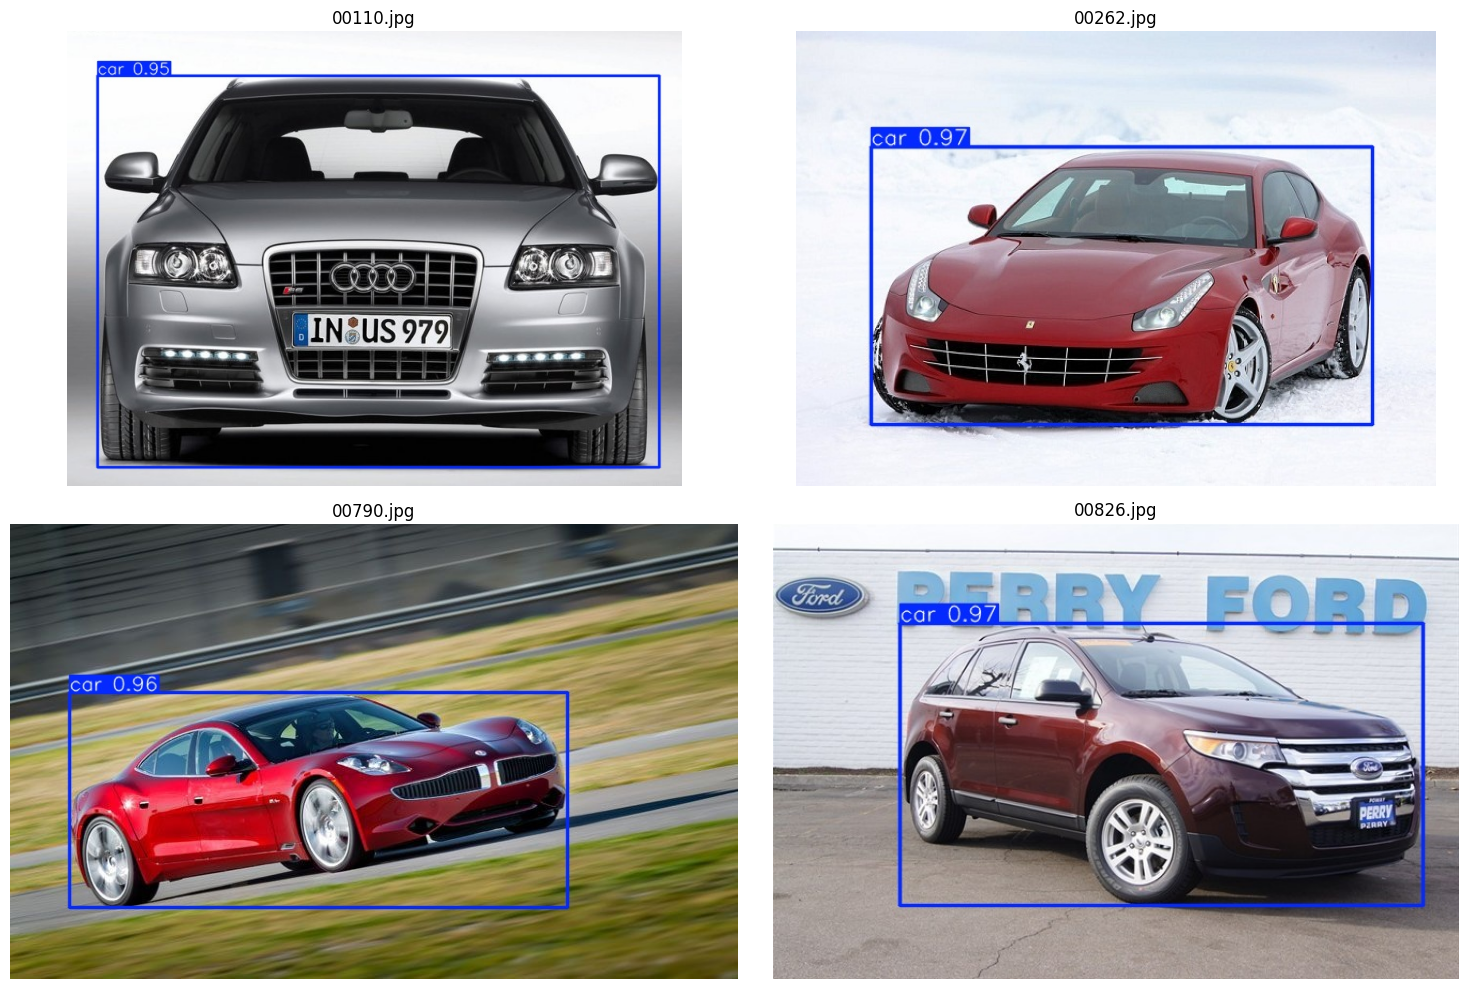

In [16]:

best_model = YOLO(str(best_weights))
sample_images = sorted((DATASET_ROOT / 'valid' / 'images').glob('*'))[:4]

for image_path in sample_images:
    best_model.predict(
        source=str(image_path),
        conf=0.25,
        project=str(RUNS_DIR),
        name='predict_colab',
        device=DEVICE,
        save=True,
        exist_ok=True,
        verbose=False,
    )

pred_dir = RUNS_DIR / 'predict_colab'
pred_images = [path for path in sorted(pred_dir.glob('*')) if path.suffix.lower() in {'.jpg', '.jpeg', '.png'}]
show_count = min(4, len(pred_images))

plt.figure(figsize=(15, 10))
for idx in range(show_count):
    plt.subplot(2, 2, idx + 1)
    image = Image.open(pred_images[idx])
    plt.imshow(image)
    plt.title(pred_images[idx].name)
    plt.axis('off')
plt.tight_layout()


Выводы:  
Ожидаемо  yolo модели дали лучший результат по сравнению с самописными ( precision в среднем 0.95 против 0.2 в пользу yolo).